In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

In [7]:
df = pd.read_csv(r"C:\Users\Akshay\Dat_science_project\Regression\Avacado_price_prediction\data\avocado.csv")
df['Date'] = pd.to_datetime(df['Date'],errors='coerce')
df = df.drop(columns=['Unnamed: 0'],errors='ignore')
df


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
18245,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
18246,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
18247,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


Dataset overview

In [8]:
print('Shape:', df.shape)
print(df.info())
print(f'Date Range:,{df['Date'].min()} - {df['Date'].max()}')
print('Regions:',df['region'].nunique())
print('Missing values:',df.isnull().sum().sum())

Shape: (18249, 13)
<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[us]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  str           
 11  year          18249 non-null  int64         
 12  region        18249 non-null  str           
dtypes: datetime64[us](1), float64(9), int64(1), str(2)
memory usage: 1.8 MB
None
Date Range:,2015-01-04 00:00:00 - 2018-03-25 00:00:

Target variable distrubution

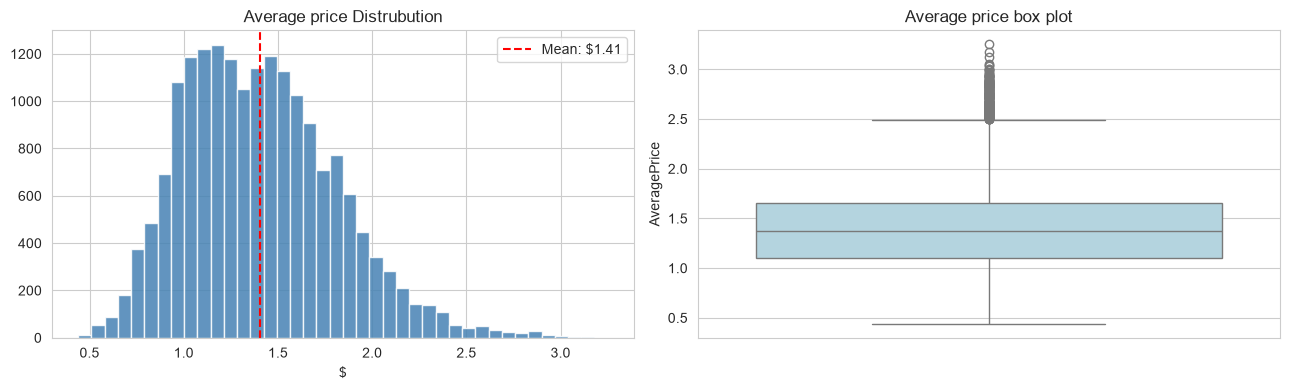

Skew:0.58
Range:$0.44-$3.25


In [9]:
fig,ax = plt.subplots(1,2,figsize=(13,4))
ax[0].hist(df['AveragePrice'],color='steelblue',bins=40,edgecolor='white',alpha=0.85)
ax[0].axvline(df['AveragePrice'].mean(),color='red',linestyle='--',label=f'Mean: ${df['AveragePrice'].mean():.2f}')
ax[0].legend()
ax[0].set_title('Average price Distrubution');ax[0].set_xlabel('$')

sns.boxplot(ax=ax[1],y=df['AveragePrice'],color='lightblue')
ax[1].set_title('Average price box plot')
plt.tight_layout();plt.show()
print(f"Skew:{df['AveragePrice'].skew():.2f}")
print(f'Range:${df['AveragePrice'].min():.2f}-${df['AveragePrice'].max():.2f}')

Univariate -Numerical features

In [11]:
df.columns

Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='str')

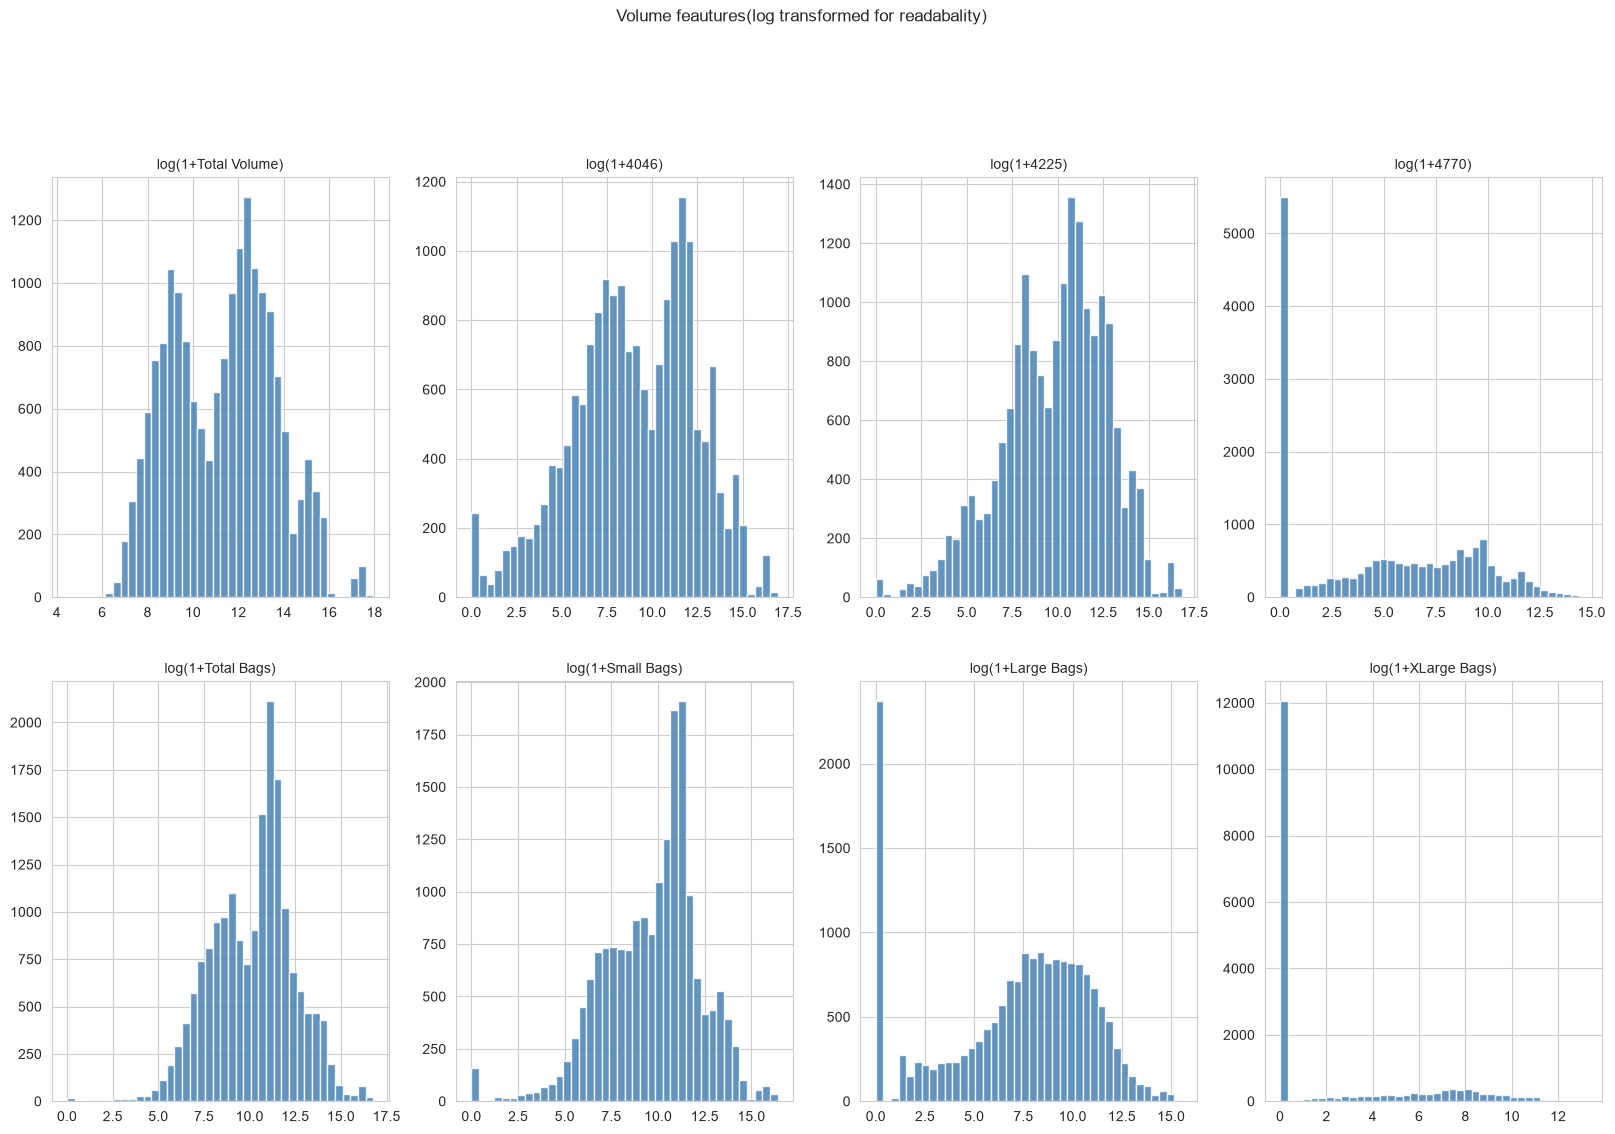

volume features heavily right skewed (warehouse counts)


In [25]:
vol_columns = ['Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

fig,ax = plt.subplots(2,4,figsize=(20,12))
ax = ax.flatten()
for i,col in enumerate(vol_columns):
    np.log1p(df[col]).hist(bins=40,ax=ax[i],color='steelblue',edgecolor='white',alpha=0.85)
    ax[i].set_title(f'log(1+{col})',fontsize=10)
plt.suptitle('Volume feautures(log transformed for readabality)',y=1.02)
plt.tight_layout;plt.show()
print('volume features heavily right skewed (warehouse counts)')

Univariate-Categorical/Time features

In [ ]:
fig,ax= plt.subplots(1,3,figsize=(20,4.5))
df['type'].value_counts()
plt.tight_layout;plt.show()